In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks

In [3]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CARGA Y PREPARACIÓN DE AMBOS DATASETS
# ==========================================
ruta_tareas = "/content/historial_cambios (21).csv"
ruta_impuestos = "/content/drive/MyDrive/Prophet_Activity/datasets/fechas_impuestos (1).csv"  # <- Tu nuevo dataset

try:
    df_tareas = pd.read_csv(ruta_tareas)
    df_impuestos = pd.read_csv(ruta_impuestos)
except FileNotFoundError as e:
    print(f"⚠️ Error al cargar los archivos: {e}")
    print("Asegúrate de subir ambos archivos a la carpeta /content/ de Colab.")
    exit()

# --- FUNCIÓN DE LIMPIEZA PARA CAMPOS MULTIVALOR (CON COMAS) ---
def limpiar_fecha_multivalor(columna, formato='%d/%m/%Y'):
    col_str = columna.astype(str).str.strip()
    col_limpia = col_str.str.split(',').str[0].str.strip()
    col_limpia = col_limpia.replace(['nan', 'NaN', ''], np.nan)
    return pd.to_datetime(col_limpia, format=formato, errors='coerce')

# --- 1.A. PROCESAMIENTO DEL DATASET DE IMPUESTOS ---
# Adaptamos las columnas a los nombres de tu nuevo dataset
df_impuestos['Fecha_Limpia'] = limpiar_fecha_multivalor(df_impuestos['Fecha'])
# Filtramos y ordenamos para extraer el Calendario Maestro Único
calendario_vencimientos = sorted(df_impuestos['Fecha_Limpia'].dropna().unique())

# --- 1.B. PROCESAMIENTO DEL DATASET DE TAREAS ---
if df_tareas['fecha_modificacion'].dtype == 'object':
    df_tareas['fecha_modificacion'] = df_tareas['fecha_modificacion'].str.replace('.', '', regex=False).str.upper()

df_tareas['fecha_modificacion'] = pd.to_datetime(df_tareas['fecha_modificacion'], format='%d/%m/%Y, %I:%M:%S %p', errors='coerce')

en_blanco = df_tareas['fecha_modificacion'].isna()
if en_blanco.any():
    df_tareas.loc[en_blanco, 'fecha_modificacion'] = pd.to_datetime(df_tareas.loc[en_blanco, 'fecha_modificacion'], format='mixed', errors='coerce')

df_tareas = df_tareas.dropna(subset=['fecha_modificacion'])
df_tareas['fecha'] = df_tareas['fecha_modificacion'].dt.date

# Procesamiento de dummies para tipos de cambios
df_con_dummies = pd.get_dummies(df_tareas, columns=['tipo_cambio'], prefix='tipo')
columnas_tipo = [col for col in df_con_dummies.columns if col.startswith('tipo_')]

# Agrupación base por día
serie_temporal = df_con_dummies.groupby('fecha').agg(
    total_tareas=('fecha_modificacion', 'count'),
    usuarios_activos=('nombre_historial', 'nunique')
).reset_index()

tabla_tipos = df_con_dummies.groupby('fecha')[columnas_tipo].sum().reset_index()
serie_temporal = pd.merge(serie_temporal, tabla_tipos, on='fecha')

serie_temporal['fecha'] = pd.to_datetime(serie_temporal['fecha'])
serie_temporal = serie_temporal.sort_values('fecha').reset_index(drop=True)

In [4]:
# ==========================================
# 2. INGENIERÍA DE CARACTERÍSTICAS (Feature Engineering)
# ==========================================
serie_temporal['dia_semana'] = serie_temporal['fecha'].dt.dayofweek
serie_temporal['dia_mes'] = serie_temporal['fecha'].dt.day
serie_temporal['es_sabado'] = (serie_temporal['dia_semana'] == 5).astype(int)
serie_temporal['es_domingo'] = (serie_temporal['dia_semana'] == 6).astype(int)
serie_temporal['es_inicio_mes'] = (serie_temporal['dia_mes'] <= 5).astype(int)

# --- CRUCE AUTOMÁTICO CON EL CALENDARIO DE IMPUESTOS ---
def calcular_distancia_vencimiento(fecha_evaluada, lista_vencimientos):
    # Encontrar los vencimientos futuros o iguales a la fecha evaluada
    futuros = [v for v in lista_vencimientos if v >= fecha_evaluada]
    if futuros:
        proximo = min(futuros)
        return (proximo - fecha_evaluada).days
    return 999  # Valor neutral si no hay más vencimientos en el horizonte

# Aplicar la lógica fila por fila en el histórico pasado
serie_temporal['dias_para_vencimiento'] = serie_temporal['fecha'].apply(
    lambda x: calcular_distancia_vencimiento(x, calendario_vencimientos)
)

# Ventana de presión crítica (0 a 5 días de distancia del impuesto)
serie_temporal['presion_vencimiento'] = ((serie_temporal['dias_para_vencimiento'] >= 0) &
                                         (serie_temporal['dias_para_vencimiento'] <= 5)).astype(int)

# Lags y Ventanas Móviles Estables
serie_temporal['tareas_ayer'] = serie_temporal['total_tareas'].shift(1)
serie_temporal['tareas_hace_7d'] = serie_temporal['total_tareas'].shift(7)
serie_temporal['media_movil_7d'] = serie_temporal['total_tareas'].shift(1).rolling(window=7).mean()

serie_temporal = serie_temporal.dropna().reset_index(drop=True)

# Definición de Predictores para el Random Forest
features_base = [
    'dia_semana', 'dia_mes', 'es_sabado', 'es_domingo', 'es_inicio_mes',
    'dias_para_vencimiento', 'presion_vencimiento',
    'tareas_ayer', 'tareas_hace_7d', 'media_movil_7d', 'usuarios_activos'
]
X_columnas = features_base + columnas_tipo

X = serie_temporal[X_columnas]
y = serie_temporal['total_tareas']

def calcular_wmape(y_real, y_pred):
    sum_real = np.sum(y_real)
    if sum_real == 0: return 0.0
    return np.sum(np.abs(y_real - y_pred)) / sum_real

# ==========================================
# 2.5 EVALUACIÓN ESTRICTA (División Temporal)
# ==========================================
dias_test = 7

if len(serie_temporal) > dias_test * 2:
    X_train, X_test = X.iloc[:-dias_test], X.iloc[-dias_test:]
    y_train, y_test = y.iloc[:-dias_test], y.iloc[-dias_test:]

    modelo_evaluacion = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=6)
    modelo_evaluacion.fit(X_train, y_train)
    y_pred_test = np.clip(modelo_evaluacion.predict(X_test), 0, None)

    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    wmape = calcular_wmape(y_test, y_pred_test)
    precision_ajustada = max(0, 100 - (wmape * 100))

    serie_temporal.loc[serie_temporal.index[-dias_test:], 'prediccion_test'] = y_pred_test
else:
    mae, rmse, wmape, precision_ajustada = None, None, None, None

In [5]:
# ==========================================
# 3. ENTRENAMIENTO EN PRODUCCIÓN (Modelo Final)
# ==========================================
modelo_futuro = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=6)
modelo_futuro.fit(X, y)

RandomForestRegressor(max_depth=6, random_state=42)

In [6]:
# ==========================================
# 4. PREDICCIÓN RECURSIVA CON CONTEXTO FISCAL AUTOMÁTICO
# ==========================================
ultima_fecha = serie_temporal['fecha'].max()
historial_valores = list(serie_temporal['total_tareas'])

perfil_usuarios = serie_temporal.groupby('dia_semana')['usuarios_activos'].mean().to_dict()
perfil_tipos = {col: serie_temporal.groupby('dia_semana')[col].mean().to_dict() for col in columnas_tipo}

futuras_fechas = []
predicciones_futuras = []

for i in range(1, 8):
    nueva_fecha = ultima_fecha + pd.Timedelta(days=i)
    n_dia_semana = nueva_fecha.dayofweek
    n_dia_mes = nueva_fecha.day

    n_es_sabado = 1 if n_dia_semana == 5 else 0
    n_es_domingo = 1 if n_dia_semana == 6 else 0
    n_es_inicio_mes = 1 if n_dia_mes <= 5 else 0

    # EL MOTOR BUSCA EN TU DATASET DE IMPUESTOS AUTOMÁTICAMENTE:
    n_dias_para_vencimiento = calcular_distancia_vencimiento(nueva_fecha, calendario_vencimientos)
    n_presion_vencimiento = 1 if (0 <= n_dias_para_vencimiento <= 5) else 0

    # Lags recursivos basados en predicciones previas
    lag_1 = historial_valores[-1]
    lag_7 = historial_valores[-7]
    movil_7d = np.mean(historial_valores[-7:])

    n_usuarios = int(round(perfil_usuarios.get(n_dia_semana, 1)))

    dict_entrada = {
        'dia_semana': n_dia_semana,
        'dia_mes': n_dia_mes,
        'es_sabado': n_es_sabado,
        'es_domingo': n_es_domingo,
        'es_inicio_mes': n_es_inicio_mes,
        'dias_para_vencimiento': n_dias_para_vencimiento,
        'presion_vencimiento': n_presion_vencimiento,
        'tareas_ayer': lag_1,
        'tareas_hace_7d': lag_7,
        'media_movil_7d': movil_7d,
        'usuarios_activos': n_usuarios
    }

    for col in columnas_tipo:
        dict_entrada[col] = perfil_tipos[col].get(n_dia_semana, 0)

    entrada_prediccion = pd.DataFrame([dict_entrada])[X_columnas]
    prediccion = max(0, int(round(modelo_futuro.predict(entrada_prediccion)[0])))

    futuras_fechas.append(nueva_fecha)
    predicciones_futuras.append(prediccion)
    historial_valores.append(prediccion)

df_futuro = pd.DataFrame({'fecha': futuras_fechas, 'pronostico': predicciones_futuras})

# ==========================================
# REPORTES Y IMPRESIÓN
# ==========================================
print("\n📊 REPORTE DE CALIFICACIÓN DEL MODELO CON CONTEXTO TRIBUTARIO AUTOMÁTICO:")
print("-" * 65)
if mae is not None:
    print(f"• Error Absoluto Medio (MAE):         {mae:.2f} tareas")
    print(f"• Raíz del Error Cuadrático (RMSE):   {rmse:.2f} tareas")
    print(f"• Error Porcentual Ponderado (wMAPE): {wmape * 100:.2f}%")
    print(f"• Precisión General Ajustada:         {precision_ajustada:.2f}%")
print("-" * 65)

print("\n📈 PRONÓSTICO DE CARGA DE TRABAJO AUTOMATIZADO (PRÓXIMOS 7 DÍAS REALES):")
for f, p in zip(futuras_fechas, predicciones_futuras):
    print(f"Fecha: {f.strftime('%Y-%m-%d')} -> Tareas estimadas: {p}")


📊 REPORTE DE CALIFICACIÓN DEL MODELO CON CONTEXTO TRIBUTARIO AUTOMÁTICO:
-----------------------------------------------------------------
• Error Absoluto Medio (MAE):         10.99 tareas
• Raíz del Error Cuadrático (RMSE):   12.02 tareas
• Error Porcentual Ponderado (wMAPE): 26.63%
• Precisión General Ajustada:         73.37%
-----------------------------------------------------------------

📈 PRONÓSTICO DE CARGA DE TRABAJO AUTOMATIZADO (PRÓXIMOS 7 DÍAS REALES):
Fecha: 2026-06-18 -> Tareas estimadas: 19
Fecha: 2026-06-19 -> Tareas estimadas: 19
Fecha: 2026-06-20 -> Tareas estimadas: 5
Fecha: 2026-06-21 -> Tareas estimadas: 6
Fecha: 2026-06-22 -> Tareas estimadas: 40
Fecha: 2026-06-23 -> Tareas estimadas: 38
Fecha: 2026-06-24 -> Tareas estimadas: 23


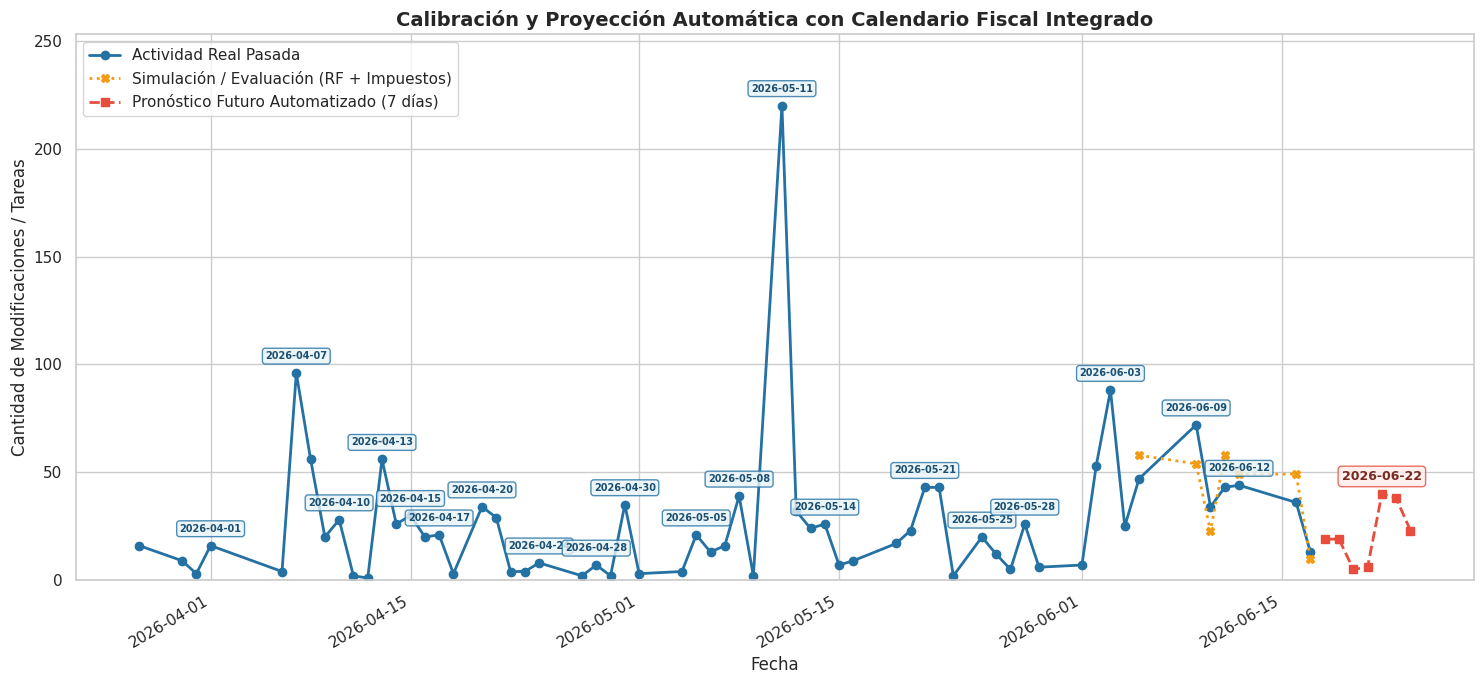

In [7]:
# ==========================================
# 5. GRÁFICA DE RENDIMIENTO Y PROYECCIÓN
# ==========================================
plt.figure(figsize=(15, 7))
sns.set_theme(style="whitegrid")

plt.plot(serie_temporal['fecha'], serie_temporal['total_tareas'], label='Actividad Real Pasada', color='#2471a3', marker='o', linewidth=2)

if mae is not None:
    df_test_plot = serie_temporal.dropna(subset=['prediccion_test'])
    plt.plot(df_test_plot['fecha'], df_test_plot['prediccion_test'], label='Simulación / Evaluación (RF + Impuestos)', color='#f39c12', linestyle=':', marker='X', linewidth=2)

plt.plot(df_futuro['fecha'], df_futuro['pronostico'], label='Pronóstico Futuro Automatizado (7 días)', color='#e74c3c', linestyle='--', marker='s', linewidth=2)

# Etiquetado de Picos Históricos
picos_hist, _ = find_peaks(serie_temporal['total_tareas'], distance=2, prominence=1)
for idx in picos_hist:
    fecha_pico = serie_temporal['fecha'].iloc[idx]
    valor_pico = serie_temporal['total_tareas'].iloc[idx]
    plt.annotate(fecha_pico.strftime('%Y-%m-%d'), xy=(fecha_pico, valor_pico), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=7, weight='bold', color='#1b4f72',
                 bbox=dict(boxstyle="round,pad=0.3", fc="#e8f4f8", ec="#2471a3", lw=1, alpha=0.8))

# Etiquetado de Picos Futuros Proyectados
picos_fut, _ = find_peaks(df_futuro['pronostico'], distance=1)
for idx in picos_fut:
    fecha_pico = df_futuro['fecha'].iloc[idx]
    valor_pico = df_futuro['pronostico'].iloc[idx]
    plt.annotate(fecha_pico.strftime('%Y-%m-%d'), xy=(fecha_pico, valor_pico), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=9, weight='bold', color='#78281f',
                 bbox=dict(boxstyle="round,pad=0.3", fc="#fdedec", ec="#e74c3c", lw=1, alpha=0.8))

plt.title('Calibración y Proyección Automática con Calendario Fiscal Integrado', fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad de Modificaciones / Tareas', fontsize=12)
plt.ylim(0, max(serie_temporal['total_tareas'].max(), df_futuro['pronostico'].max()) * 1.15)
plt.gcf().autofmt_xdate()
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

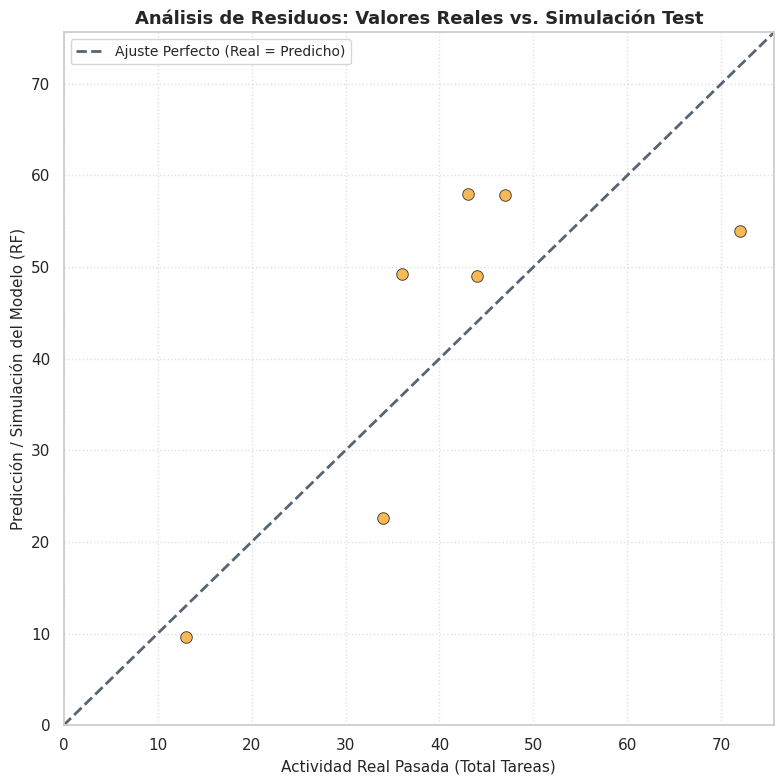

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Filtrar los datos eliminando filas donde no hubo predicción de prueba (igual que en tu gráfica base)
df_evaluacion = serie_temporal.dropna(subset=['prediccion_test'])

plt.figure(figsize=(8, 8))
sns.set_theme(style="whitegrid")

# Gráfico de dispersión cruzando Real vs Predicho
sns.scatterplot(
    x=df_evaluacion['total_tareas'],
    y=df_evaluacion['prediccion_test'],
    alpha=0.7,
    color='#f39c12',
    s=70,
    edgecolor='black'
)

# Línea de referencia ideal de 45 grados (Y = X)
lims = [0, max(df_evaluacion['total_tareas'].max(), df_evaluacion['prediccion_test'].max()) * 1.05]
plt.plot(lims, lims, color='#2c3e50', linestyle='--', alpha=0.8, linewidth=2, label='Ajuste Perfecto (Real = Predicho)')

plt.title('Análisis de Residuos: Valores Reales vs. Simulación Test', fontsize=13, weight='bold')
plt.xlabel('Actividad Real Pasada (Total Tareas)', fontsize=11)
plt.ylabel('Predicción / Simulación del Modelo (RF)', fontsize=11)
plt.xlim(lims)
plt.ylim(lims)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

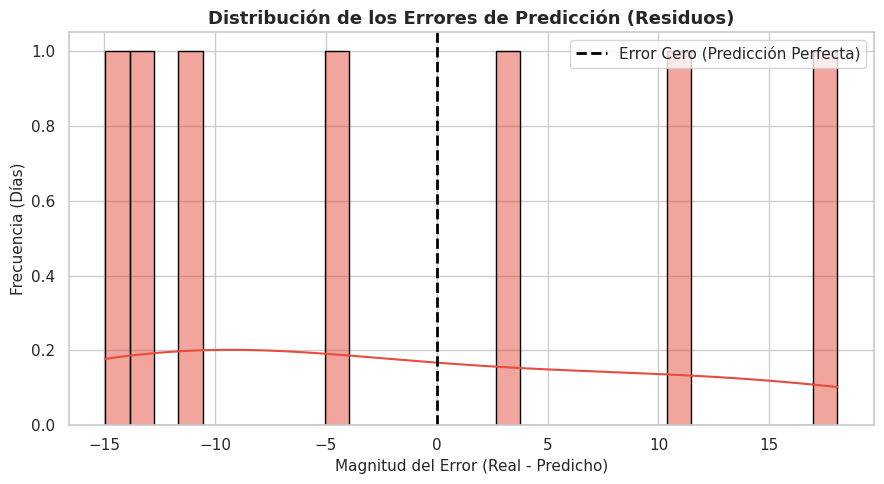

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular la diferencia (Residuos) en el set de prueba
df_evaluacion = serie_temporal.dropna(subset=['prediccion_test'])
residuos = df_evaluacion['total_tareas'] - df_evaluacion['prediccion_test']

# 2. Graficar la distribución
plt.figure(figsize=(9, 5))
sns.histplot(residuos, kde=True, color='#e74c3c', bins=30, edgecolor='black')

# Línea en 0 (Predicción perfecta)
plt.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Error Cero (Predicción Perfecta)')

plt.title('Distribución de los Errores de Predicción (Residuos)', fontsize=13, weight='bold')
plt.xlabel('Magnitud del Error (Real - Predicho)', fontsize=11)
plt.ylabel('Frecuencia (Días)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

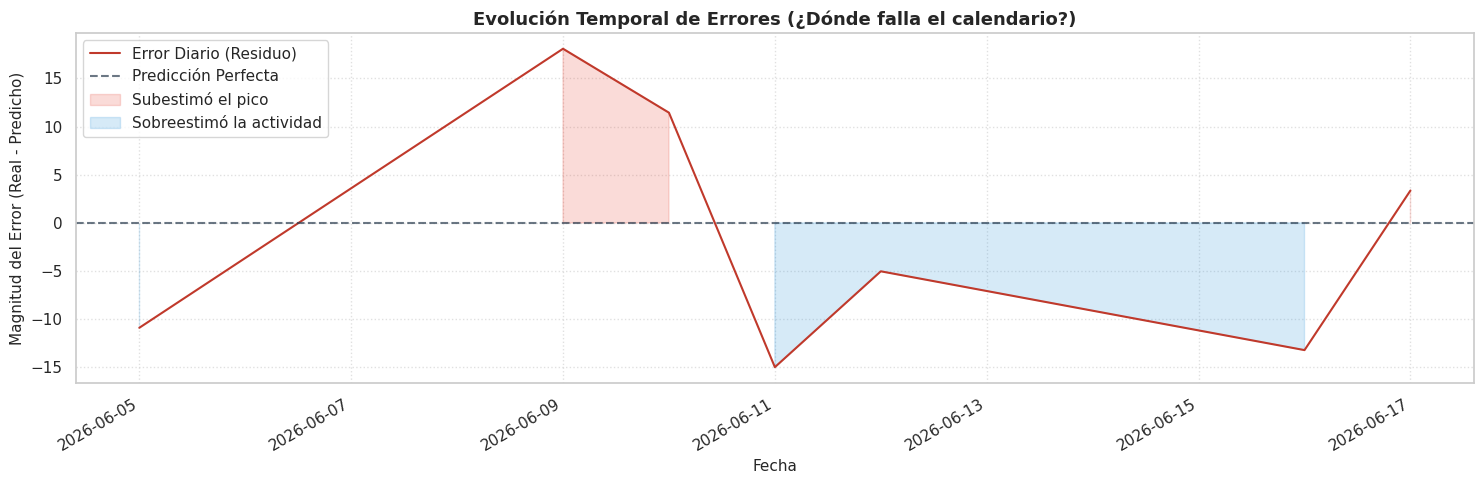

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Filtrar filas válidas para la evaluación del test
df_residuos = serie_temporal.dropna(subset=['prediccion_test']).copy()

# 2. Calcular el residuo puro (Real - Predicho)
df_residuos['residuo'] = df_residuos['total_tareas'] - df_residuos['prediccion_test']

# 3. Graficar la evolución temporal del error
plt.figure(figsize=(15, 5))
plt.plot(df_residuos['fecha'], df_residuos['residuo'], color='#c0392b', linewidth=1.5, label='Error Diario (Residuo)')
plt.axhline(y=0, color='#2c3e50', linestyle='--', alpha=0.7, linewidth=1.5, label='Predicción Perfecta')

# Rellenar áreas para diferenciar sobreestimaciones de subestimaciones
plt.fill_between(df_residuos['fecha'], df_residuos['residuo'], 0,
                 where=(df_residuos['residuo'] > 0), color='#e74c3c', alpha=0.2, label='Subestimó el pico')
plt.fill_between(df_residuos['fecha'], df_residuos['residuo'], 0,
                 where=(df_residuos['residuo'] < 0), color='#3498db', alpha=0.2, label='Sobreestimó la actividad')

plt.title('Evolución Temporal de Errores (¿Dónde falla el calendario?)', fontsize=13, weight='bold')
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Magnitud del Error (Real - Predicho)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

/tmp/ipykernel_432/1782134501.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


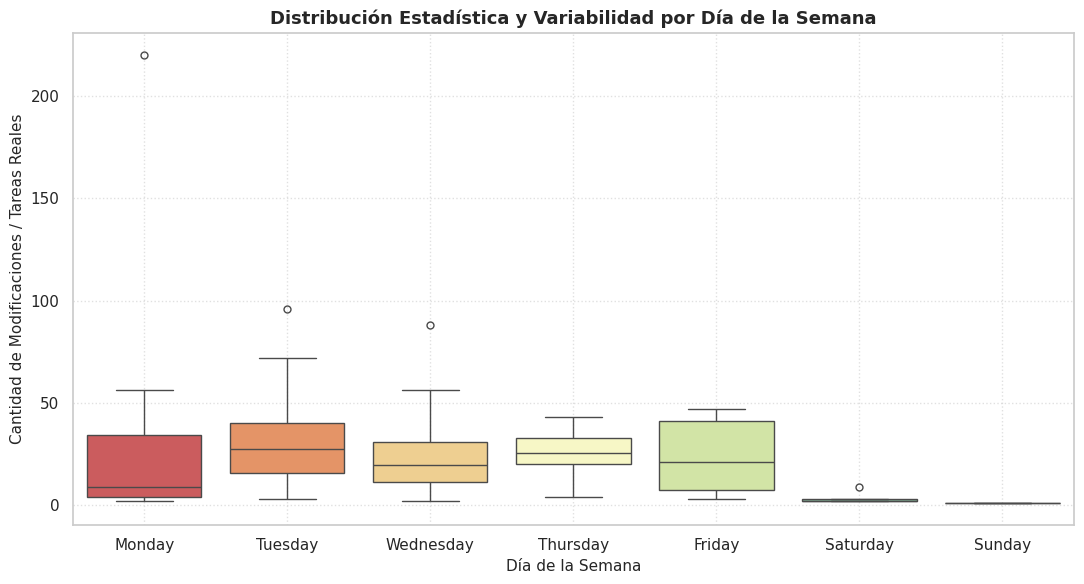

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_box = serie_temporal.copy()
df_box['fecha_dt'] = pd.to_datetime(df_box['fecha'])
df_box['Día Semana'] = df_box['fecha_dt'].dt.day_name()

# Forzar el orden natural de la semana para la lectura del gráfico
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

# Crear el Boxplot
sns.boxplot(
    x='Día Semana',
    y='total_tareas',
    data=df_box,
    order=orden_dias,
    palette='Spectral',
    fliersize=5  # Tamaño de los puntos atípicos
)

plt.title('Distribución Estadística y Variabilidad por Día de la Semana', fontsize=13, weight='bold')
plt.xlabel('Día de la Semana', fontsize=11)
plt.ylabel('Cantidad de Modificaciones / Tareas Reales', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

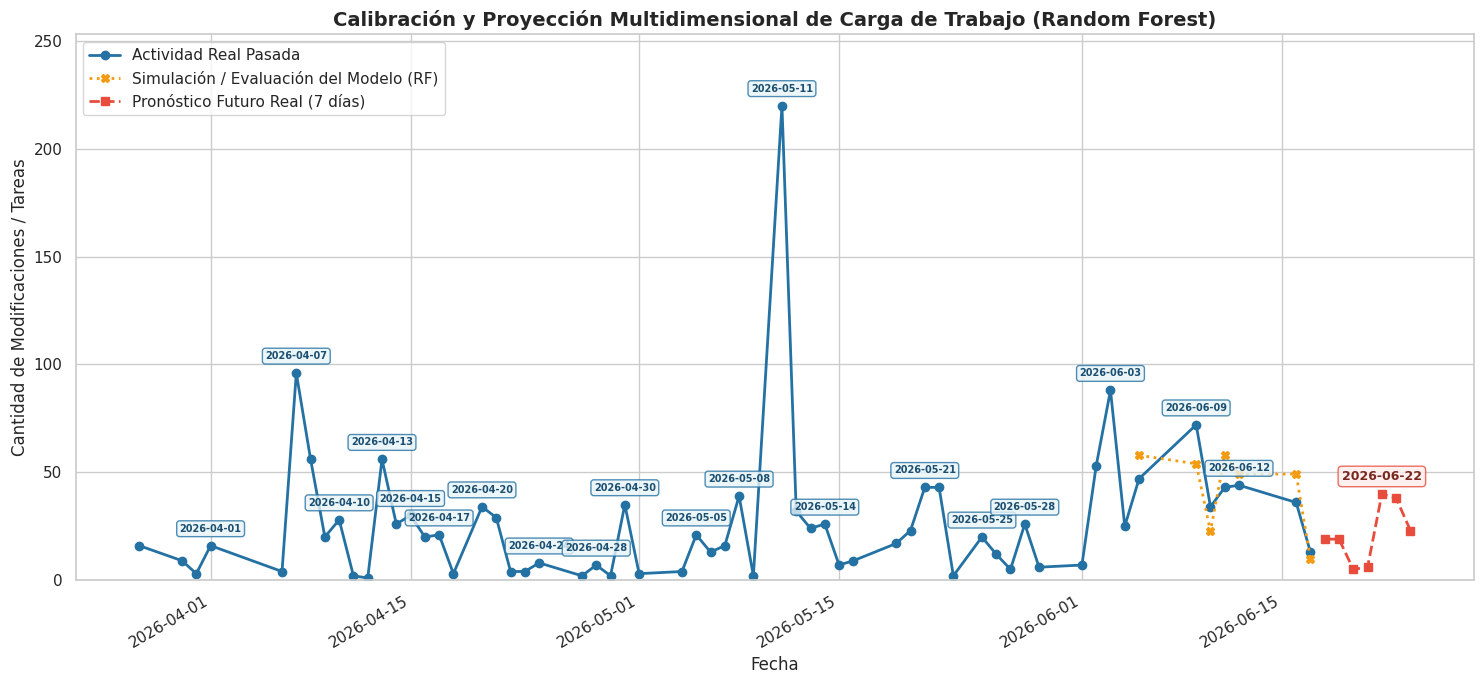

In [12]:
# ==========================================
# 5. GRÁFICA DE TENDENCIA, VALIDACIÓN Y PRONÓSTICO
# ==========================================
plt.figure(figsize=(15, 7))
sns.set_theme(style="whitegrid")

plt.plot(serie_temporal['fecha'], serie_temporal['total_tareas'], label='Actividad Real Pasada', color='#2471a3', marker='o', linewidth=2)

if mae is not None:
    df_test_plot = serie_temporal.dropna(subset=['prediccion_test'])
    plt.plot(df_test_plot['fecha'], df_test_plot['prediccion_test'], label='Simulación / Evaluación del Modelo (RF)', color='#f39c12', linestyle=':', marker='X', linewidth=2)

plt.plot(df_futuro['fecha'], df_futuro['pronostico'], label='Pronóstico Futuro Real (7 días)', color='#e74c3c', linestyle='--', marker='s', linewidth=2)

# Etiquetado de Picos
picos_hist, _ = find_peaks(serie_temporal['total_tareas'], distance=2, prominence=1)
for idx in picos_hist:
    fecha_pico = serie_temporal['fecha'].iloc[idx]
    valor_pico = serie_temporal['total_tareas'].iloc[idx]
    plt.annotate(fecha_pico.strftime('%Y-%m-%d'), xy=(fecha_pico, valor_pico), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=7, weight='bold', color='#1b4f72',
                 bbox=dict(boxstyle="round,pad=0.3", fc="#e8f4f8", ec="#2471a3", lw=1, alpha=0.8))

picos_fut, _ = find_peaks(df_futuro['pronostico'], distance=1)
for idx in picos_fut:
    fecha_pico = df_futuro['fecha'].iloc[idx]
    valor_pico = df_futuro['pronostico'].iloc[idx]
    plt.annotate(fecha_pico.strftime('%Y-%m-%d'), xy=(fecha_pico, valor_pico), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=9, weight='bold', color='#78281f',
                 bbox=dict(boxstyle="round,pad=0.3", fc="#fdedec", ec="#e74c3c", lw=1, alpha=0.8))

plt.title('Calibración y Proyección Multidimensional de Carga de Trabajo (Random Forest)', fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad de Modificaciones / Tareas', fontsize=12)
plt.ylim(0, max(serie_temporal['total_tareas'].max(), df_futuro['pronostico'].max()) * 1.15)
plt.gcf().autofmt_xdate()
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()